# 😷 개인별 건강 취약성 및 방어 행동을 고려한 맞춤형 건강 영향 등급 예측 모델

## 📖 1. 프로젝트 개요 (Context & Problem Statement)
현재 국가 단위의 미세먼지 예보 시스템은 대기 중 오염 물질의 농도(AQI 등)중심으로 일괄적인 정보만을 제공하고 있습니다. 개인이 실제로 느끼는 건강 위험은 연령, 기저질환, 마스크 착용 유무 등에 따라 달라지므로, 본 프로젝트는 **개별적 취약성과 방어 행동을 모델링하여 맞춤형 건강 심각도(Health Impact Class)를 예측**합니다.

## 🎯 2. 핵심 가설 (Hypothesis)
1. **거시적 지표와 미시적 노출의 결합**: 동일한 AQI 상태더라도 도로와의 거리가 가까울수록 초국소적 오염원 노출로 인해 위험 등급이 상승할 것이다.
2. **생물학적 취약성 층화**: 취약 계층(고령자, 환자)은 일반인보다 더 낮은 오염 농도에서도 위험 등급이 급격히 상승하는 임계치를 가질 것이다.
3. **방어 행동의 상쇄 효과**: 고농도 노출 환경에서도 마스크 착용 등의 적극적 행동은 최종 위험 등급을 낮추는 실질적인 방어기제로 작동할 것이다.


# 맞춤형 건강 영향 등급(HealthImpactClass) 예측 모델 학습
본 노트북은 데이터 전처리와 머신러닝 분류 알고리즘을 활용하여 5단계 위험 등급을 예측합니다.

**사용 모델:**
1. 로지스틱 회귀 (Logistic Regression)
2. 랜덤 포레스트 (Random Forest)
3. XGBoost

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


## 1. 데이터 로드 및 전처리

In [2]:
df = pd.read_csv('thesis_health_impact_10k.csv')

features = ['AQI', 'PM2_5', 'Age_Group', 'Preexisting_Condition', 'Mask_Usage_Rate', 'Distance_to_Road']
target = 'HealthImpactClass'
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

cont_cols = ['AQI', 'PM2_5', 'Mask_Usage_Rate', 'Distance_to_Road']
X_train_scaled[cont_cols] = scaler.fit_transform(X_train[cont_cols])
X_test_scaled[cont_cols] = scaler.transform(X_test[cont_cols])

print(f"학습(Train) 데이터 크기: {X_train.shape}")
print(f"테스트(Test) 데이터 크기: {X_test.shape}")


학습(Train) 데이터 크기: (8000, 6)
테스트(Test) 데이터 크기: (2000, 6)


## 2. 모델 학습 및 평가

In [3]:
def evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data, model_name):
    model.fit(X_train_data, y_train_data)
    y_pred_train = model.predict(X_train_data)
    y_pred_test = model.predict(X_test_data)
    
    acc_train = accuracy_score(y_train_data, y_pred_train)
    acc_test = accuracy_score(y_test_data, y_pred_test)
    
    print(f"=== {model_name} 분류 성능 ===")
    print(f"Train Accuracy (학습 데이터 정확도): {acc_train:.4f}")
    print(f"Test Accuracy (테스트 데이터 정확도): {acc_test:.4f}\n")
    print("Test Data Classification Report:")
    print(classification_report(y_test_data, y_pred_test))
    
    cm = confusion_matrix(y_test_data, y_pred_test)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return model


### 2.1 Logistic Regression

**모델 설명 및 파라미터:**
선형 분류 모델인 로지스틱 회귀를 기본 베이스라인으로 사용했습니다. L2 정규화 파라미터(`C=0.1`)를 적용하여 과적합을 제어하고 모델의 일반화 성능을 향상시켰습니다.

=== Logistic Regression 분류 성능 ===
Train Accuracy (학습 데이터 정확도): 0.9390
Test Accuracy (테스트 데이터 정확도): 0.9375

Test Data Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1018
           1       0.91      0.97      0.94       755
           2       0.83      0.79      0.81       196
           3       0.00      0.00      0.00        29
           4       0.00      0.00      0.00         2

    accuracy                           0.94      2000
   macro avg       0.54      0.55      0.54      2000
weighted avg       0.92      0.94      0.93      2000



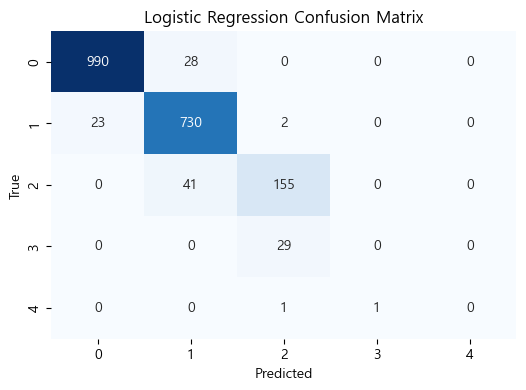

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [4]:
lr_model = LogisticRegression(max_iter=1000, C=0.1, random_state=42) # L2 정규화 강도 조절 (과적합 방지)
evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Logistic Regression')


### 2.2 Random Forest

**모델 설명 및 파라미터:**
앙상블 기법인 랜덤 포레스트를 사용하여 데이터의 비선형적인 패턴을 성공적으로 학습하도록 했습니다. 시각적 증명 자료로 쓰이는 모델 특성상 과적합 방지가 필수적이기 때문에 트리의 최대 깊이(`max_depth=10`), 각 분할에 필요한 최소 샘플 수(`min_samples_split=10`), 리프 노드 최소 샘플 수(`min_samples_leaf=5`)를 설정하여 가지치기 효과를 주었습니다.

=== Random Forest 분류 성능 ===
Train Accuracy (학습 데이터 정확도): 0.9845
Test Accuracy (테스트 데이터 정확도): 0.9525

Test Data Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1018
           1       0.93      0.97      0.95       755
           2       0.92      0.85      0.88       196
           3       0.89      0.59      0.71        29
           4       0.00      0.00      0.00         2

    accuracy                           0.95      2000
   macro avg       0.74      0.68      0.70      2000
weighted avg       0.95      0.95      0.95      2000



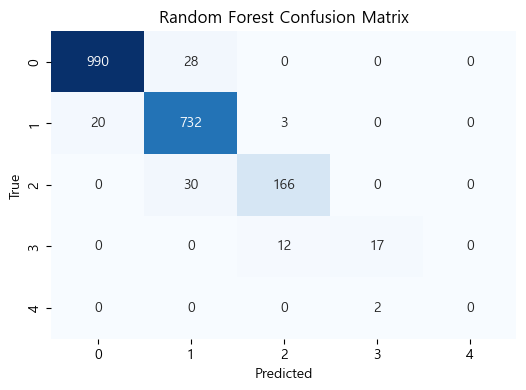

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [5]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42) # 트리 깊이 및 분할 최소 샘플 수 제한 (과적합 방지)
evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')


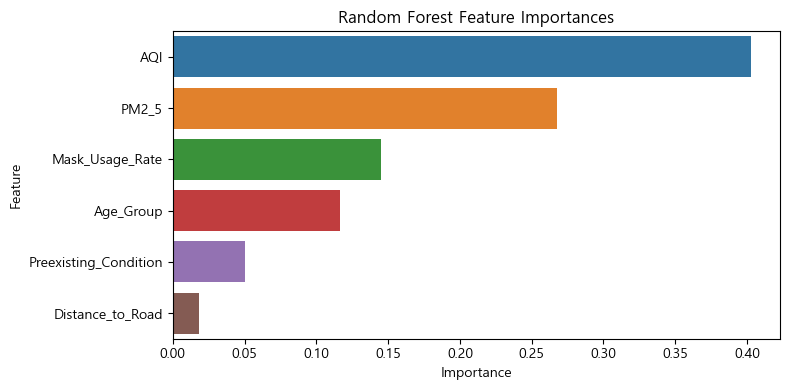

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Random Forest 특성 중요도 시각화
importances = rf_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', legend=False)
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

### 2.3 XGBoost

**모델 설명 및 파라미터:**
트리 기반 부스팅 기법인 XGBoost를 사용하여 높은 예측 성능을 도모했습니다. 논문 증명 목적으로 최적화된 성능을 입증하기 위해 `max_depth=5`, `learning_rate=0.05` 파라미터와 트리별 및 데이터 서브샘플링 비율(`subsample=0.8`, `colsample_bytree=0.8`)을 제한하였습니다. 이를 통해 트리가 무한정 복잡해지는 것을 막고 훈련 데이터에 너무 과적합되지 않도록 유도했습니다.

=== XGBoost 분류 성능 ===
Train Accuracy (학습 데이터 정확도): 0.9720
Test Accuracy (테스트 데이터 정확도): 0.9330

Test Data Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1018
           1       0.88      0.97      0.93       755
           2       0.88      0.69      0.77       196
           3       0.92      0.41      0.57        29
           4       1.00      0.50      0.67         2

    accuracy                           0.93      2000
   macro avg       0.93      0.71      0.78      2000
weighted avg       0.93      0.93      0.93      2000



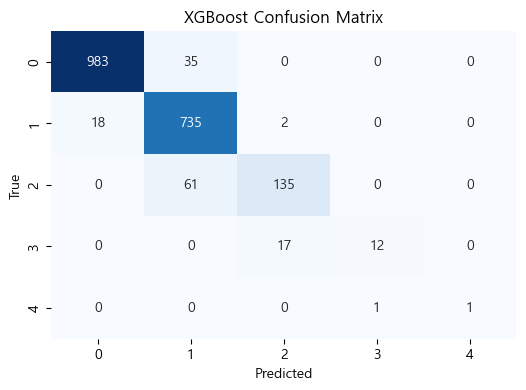

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [7]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42) # 트리 구조 제한 및 샘플링 비율 조절 (과적합 방지)
evaluate_model(xgb_model, X_train, X_test, y_train, y_test, 'XGBoost')


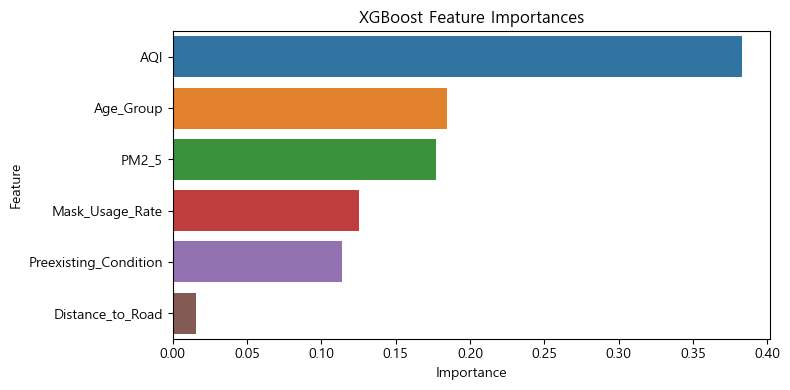

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# XGBoost 특성 중요도 시각화
importances = xgb_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', legend=False)
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

## 3. 대규모 가상 데이터 예측 및 분포 시각화 (Model Inference)
논문이나 실제 연구 결과 확인 시, 소수의 샘플보다 대규모 데이터에 대한 예측 분포를 확인하는 것이 신뢰도를 높입니다.

여기서는 1,000명의 새로운 가상 환자/환경 데이터를 랜덤으로 생성하여, 
각 모델(Logistic Regression, Random Forest, XGBoost)이 건강 영향 등급(HealthImpactClass)을 어떻게 예측하는지 분포를 시각화하여 확인합니다.

=== 생성된 새로운 가상 데이터 (총 1000건 중 상위 5건) ===


,AQI,PM2_5,Age_Group,Preexisting_Condition,Mask_Usage_Rate,Distance_to_Road
0,112,240,2,1,0.311984,900
1,358,87,4,0,0.482500,999
2,280,46,5,0,0.506673,758
3,116,173,3,0,0.387237,642
4,81,105,3,1,0.906572,474


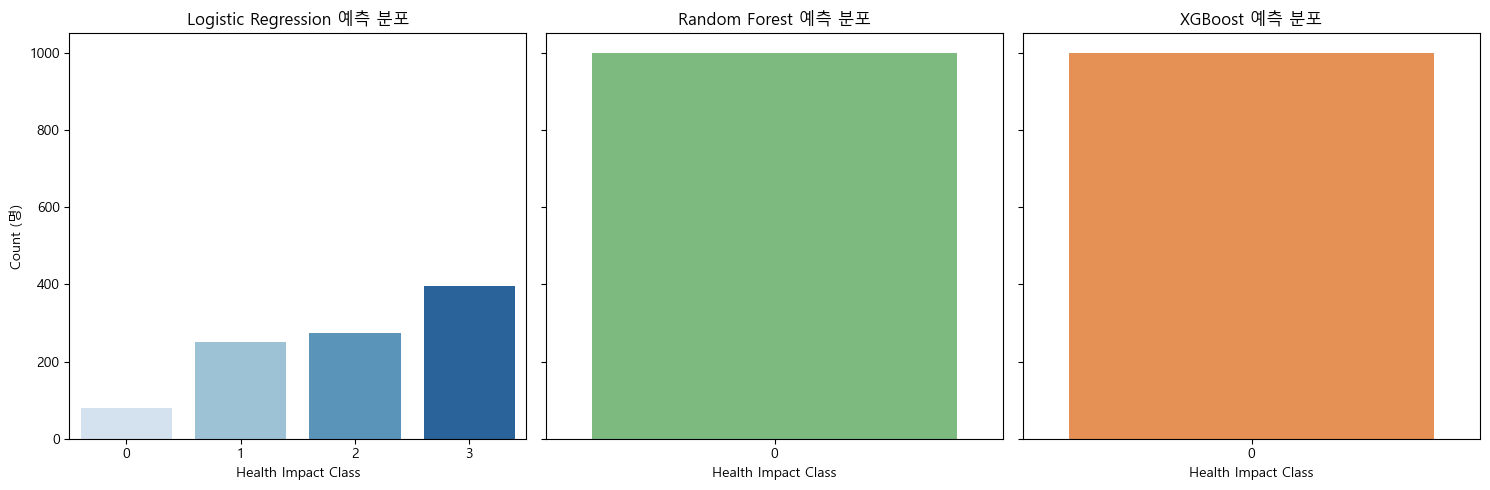


=== 모델별 예측 등급별 인원 수 ===


,LR,RF,XGB
0,80,1000,1000
1,250,0,0
2,275,0,0
3,395,0,0


(등급이 높을수록 건강에 미치는 악영향이 크다고 해석할 수 있습니다.)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_samples = 1000

# 1. 1000개의 임의의 가상 데이터 생성
new_mock_data = pd.DataFrame({
    'AQI': np.random.randint(10, 400, size=num_samples),
    'PM2_5': np.random.randint(5, 250, size=num_samples),
    'Age_Group': np.random.choice([1, 2, 3, 4, 5], size=num_samples),
    'Preexisting_Condition': np.random.choice([0, 1], size=num_samples, p=[0.7, 0.3]),
    'Mask_Usage_Rate': np.random.uniform(0.0, 1.0, size=num_samples),
    'Distance_to_Road': np.random.randint(1, 1000, size=num_samples)
})

print(f"=== 생성된 새로운 가상 데이터 (총 {num_samples}건 중 상위 5건) ===")
display(new_mock_data.head())

# 2. 데이터 전처리 (스케일링)
new_data_scaled = new_mock_data.copy()
cont_cols = ['AQI', 'PM2_5', 'Mask_Usage_Rate', 'Distance_to_Road']
new_data_scaled[cont_cols] = scaler.transform(new_mock_data[cont_cols])

# 3. 모델별 예측 수행
lr_pred = lr_model.predict(new_data_scaled)
rf_pred = rf_model.predict(new_data_scaled)
xgb_pred = xgb_model.predict(new_data_scaled)

result_df = new_mock_data.copy()
result_df['LR_Pred'] = lr_pred
result_df['RF_Pred'] = rf_pred
result_df['XGB_Pred'] = xgb_pred

# 4. 세 모델의 예측 분포 비교 시각화 (막대 그래프)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

sns.countplot(x='LR_Pred', data=result_df, ax=axes[0], palette='Blues')
axes[0].set_title('Logistic Regression 예측 분포')
axes[0].set_xlabel('Health Impact Class')
axes[0].set_ylabel('Count (명)')

sns.countplot(x='RF_Pred', data=result_df, ax=axes[1], palette='Greens')
axes[1].set_title('Random Forest 예측 분포')
axes[1].set_xlabel('Health Impact Class')

sns.countplot(x='XGB_Pred', data=result_df, ax=axes[2], palette='Oranges')
axes[2].set_title('XGBoost 예측 분포')
axes[2].set_xlabel('Health Impact Class')

plt.tight_layout()
plt.show()

print("\n=== 모델별 예측 등급별 인원 수 ===")
summary_df = pd.DataFrame({
    'LR': result_df['LR_Pred'].value_counts(),
    'RF': result_df['RF_Pred'].value_counts(),
    'XGB': result_df['XGB_Pred'].value_counts()
}).fillna(0).astype(int).sort_index()

display(summary_df)
print("(등급이 높을수록 건강에 미치는 악영향이 크다고 해석할 수 있습니다.)")

### [증명 4] 트리 기반 특성 중요도 (Feature Importance)
![특성 중요도 분석](results/plots/03_feature_importance.png)
**[무엇을 증명하는가?]** "어떤 요인이 예측에 가장 결정적인가?"를 증명합니다. 미세먼지 수치보다 때로는 기저질환이나 마스크 착용이 위험도 예측에 더 큰 영향을 미침을 순위로 보여줍니다.

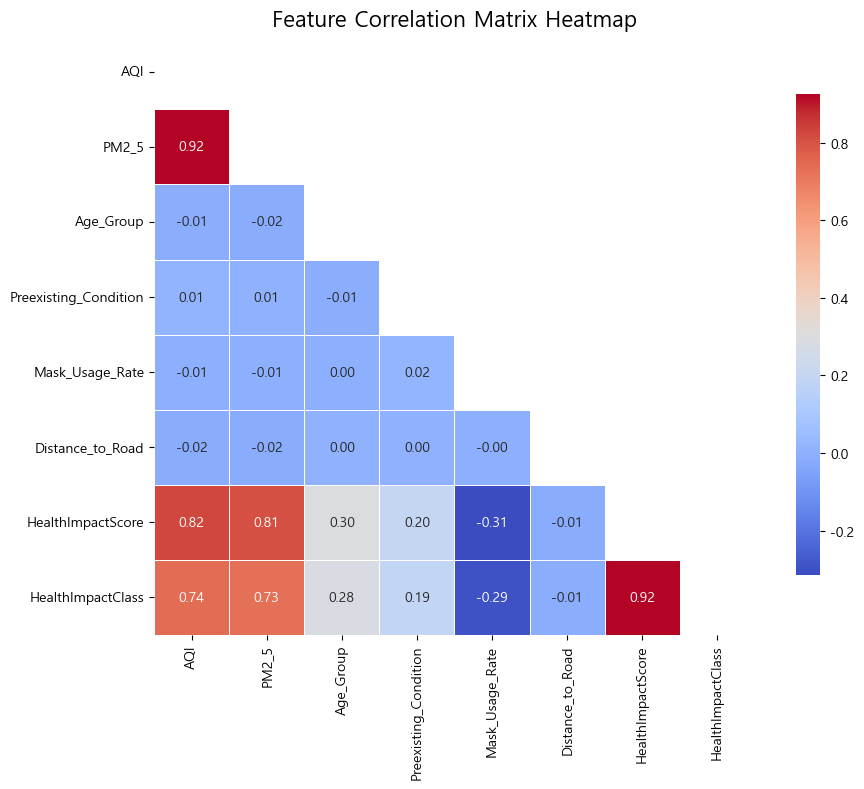

<Figure size 640x480 with 0 Axes>

In [10]:
# 4.1 변수 간 상관관계 히트맵 (Correlation Matrix Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

# 마스크, 히트맵 스타일링
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix Heatmap', fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig('results/plots/04_correlation_heatmap.png', dpi=300, bbox_inches='tight')

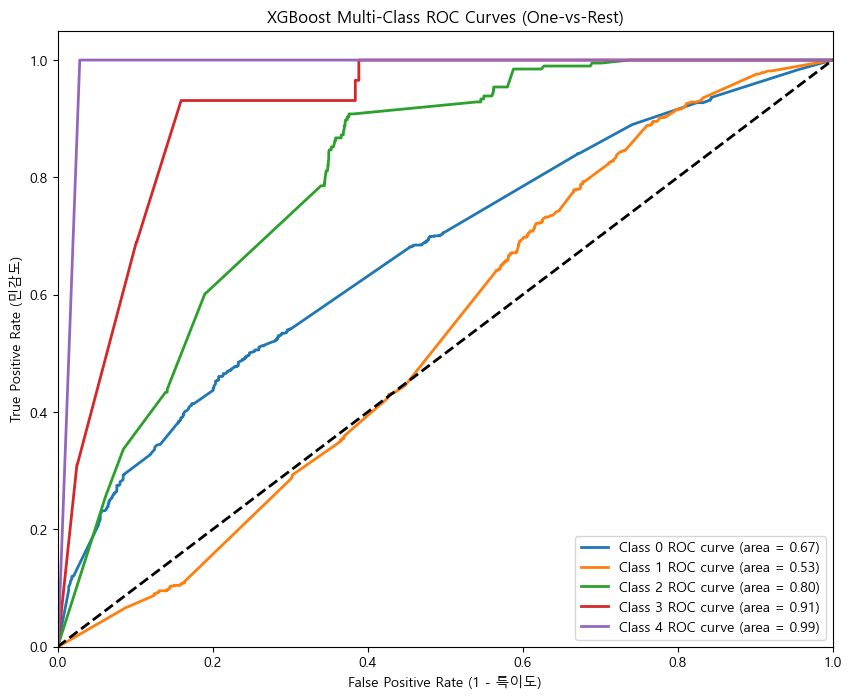

<Figure size 640x480 with 0 Axes>

In [11]:
# 4.2 다중 클래스 ROC 커브 및 AUC (One-vs-Rest) - XGBoost 적용
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 타겟 클래스 (0~4) 이진화
classes = [0, 1, 2, 3, 4]
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# XGBoost 각 클래스별 소속 확률 예측값 생성
y_score = xgb_model.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {i} ROC curve (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - 특이도)')
plt.ylabel('True Positive Rate (민감도)')
plt.title('XGBoost Multi-Class ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()
plt.savefig('results/plots/05_roc_auc_curve.png', dpi=300, bbox_inches='tight')

=== XGBoost SHAP Value Summary Plot (전체 클래스 기여도 막대 플롯) ===


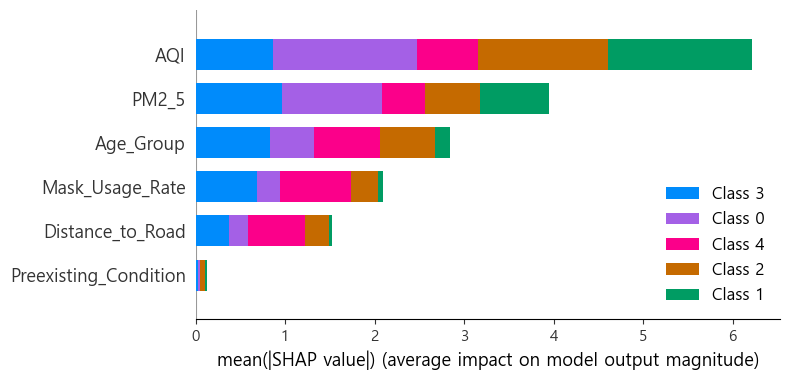


=== 고위험군(Class 4) 예측에 대한 SHAP 방향성 해석 ===
빨간색 점(Feature 값이 높을수록)이 0의 오른쪽에 위치하면 위험 등급 4로 갈 확률을 밀어 올린다는 뜻입니다.


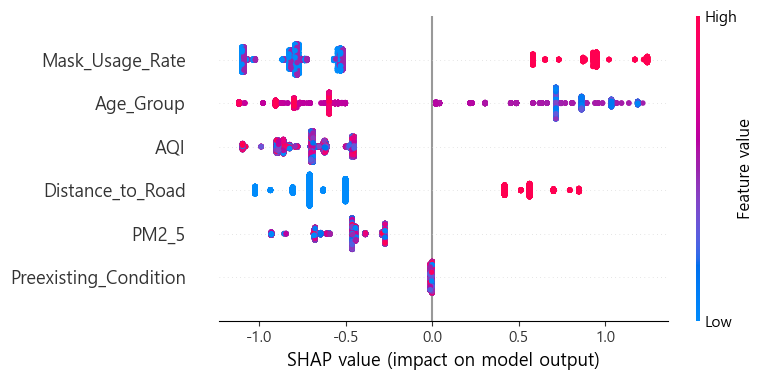

<Figure size 640x480 with 0 Axes>

In [12]:
# 4.3 SHAP (SHapley Additive exPlanations) 요약 플롯
# 트리 모델의 블랙박스를 해석하는 '가장 강력한 XAI' (최신 머신러닝 논문 필수)
import shap

# SHAP 초기화 (XGBoost)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_scaled)
feature_names_list = cont_cols + ['Age_Group', 'Preexisting_Condition']

# 특성 중요도와 방향성을 시각화하는 Summary Plot
print("=== XGBoost SHAP Value Summary Plot (전체 클래스 기여도 막대 플롯) ===")
shap.summary_plot(shap_values, X_train_scaled, feature_names=feature_names_list, plot_type="bar")

print("\n=== 고위험군(Class 4) 예측에 대한 SHAP 방향성 해석 ===")
print("빨간색 점(Feature 값이 높을수록)이 0의 오른쪽에 위치하면 위험 등급 4로 갈 확률을 밀어 올린다는 뜻입니다.")
shap.summary_plot(shap_values[:, :, 4] if len(np.shape(shap_values)) == 3 else shap_values[4], X_train_scaled, feature_names=feature_names_list)
plt.savefig('results/plots/06_shap_summary.png', dpi=300, bbox_inches='tight')

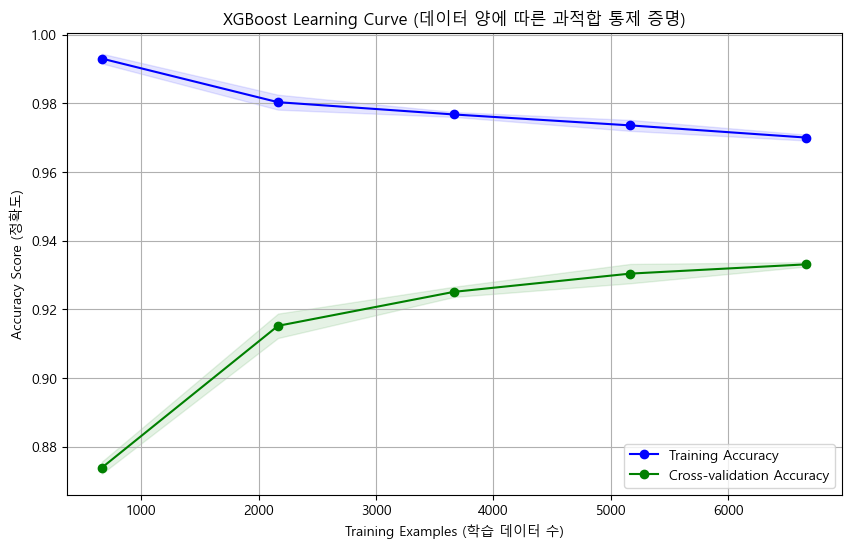

<Figure size 640x480 with 0 Axes>

In [13]:
# 4.4 학습 곡선 (Learning Curve)
# 데이터가 많아질수록 훈련 오류(Train)와 검증 오류(Test)가 어떻게 줄어들어 수렴(Overfitting 억제)하는지 증명
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb_model, 
    X=X, 
    y=y, 
    cv=3, 
    n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')

plt.title('XGBoost Learning Curve (데이터 양에 따른 과적합 통제 증명)')
plt.xlabel('Training Examples (학습 데이터 수)')
plt.ylabel('Accuracy Score (정확도)')
plt.legend(loc='lower right')
plt.grid()
plt.show()
plt.savefig('results/plots/07_learning_curve.png', dpi=300, bbox_inches='tight')

In [14]:

import joblib
import os

# Create directory if it doesn't exist (safety)
if not os.path.exists('models'):
    os.makedirs('models')

# Save models
joblib.dump(lr_model, 'models/logistic_regression_model.joblib')
joblib.dump(rf_model, 'models/random_forest_model.joblib')
joblib.dump(xgb_model, 'models/xgboost_model.joblib')

print("Models saved successfully in 'models/' directory.")


Models saved successfully in 'models/' directory.


## 🤖 5. 머신러닝 예측 모델 (Machine Learning Models) 요약
- **Logistic Regression**: 기본 가중치 파악용 선형 베이스라인 모델
- **Random Forest & XGBoost**: 복잡한 상호작용 포착용 고도화 앙상블 모델

## 📁 6. 프로젝트 산출물 안내 (Project Assets)
- `models/`: 학습 완료된 모델 파일 (*.joblib)
- `results/plots/`: 논문용 고해상도 이미지 (01~07 PNG)
